# Spot Agent: cell2location Visium Deconvolution

This notebook exercises the **Spot Agent** (`cell2location_visium_deconvolution_tool`) on a 10x Visium dataset paired with a matched single-cell RNA-seq reference, then visualizes the per-spot cell type abundances.

Follows the same structure as `figure_recreation_lohoff-2b.ipynb`.

> ⚠️ **Compute requirements**
>
> Training both the reference regression model and the spatial deconvolution model benefits from GPU acceleration. With the Spot Agent's reduced-epoch defaults (`regression_max_epochs=50`, `spatial_max_epochs=300`), a full run still takes several minutes.

In [2]:
TASK = "spot_deconvolution_visium_heart"

In [6]:
import os
import shutil
import sys
from functools import partial
from pathlib import Path
from queue import Queue

from langchain_core.messages import HumanMessage
from openai import RateLimitError
import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path.cwd().parent / "src"))

### configure logging
from config import DATA_DIR
from notebook_utils import tee_output
log_path = Path.cwd() / f"outputs/{TASK}/transcript.log"
log_path.parent.mkdir(parents=True, exist_ok=True)
log_path.write_text("")
tee = partial(tee_output, path=log_path)

### reset data directory
from notebook_utils import _reset_data_directories
_reset_data_directories()

### Task Files

Only the **Visium** spatial dataset is staged locally (downloaded from Google Drive into `DATA_DIR/dataset/` via [`gdown`](https://github.com/wkentaro/gdown)). The **scRNA-seq reference is NOT provided** — the agent is expected to locate and download a suitable human heart reference from CZI CELLxGENE on its own using the `single_cell` agent's tools (`query_cellxgene_census_live_tool` + `retrieve_cellxgene_single_cell_tool`).

- **Visium**: 10x Visium human heart sample ([Drive link](https://drive.google.com/file/d/1gUNi8481XaTkknIZuJiCXi-Nk_wopkJe/view?usp=drive_link)).

In [11]:
### Task Files — download Visium only from Google Drive

try:
    import gdown
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "gdown"])
    import gdown

visium_filename = "visium-OCT_LA_raw.h5ad"
visium_drive_id = "1gUNi8481XaTkknIZuJiCXi-Nk_wopkJe"

dataset_dir = DATA_DIR / "dataset"
dataset_dir.mkdir(parents=True, exist_ok=True)

visium_dst = dataset_dir / visium_filename
if visium_dst.exists():
    print(f"Already present, skipping download: {visium_dst}")
else:
    print(f"Downloading {visium_filename} from Google Drive ({visium_drive_id})...")
    gdown.download(id=visium_drive_id, output=str(visium_dst), quiet=False)

print("\nFiles present in DATA_DIR:", end="\n - ")
files = [str(f.relative_to(DATA_DIR)) for f in DATA_DIR.rglob("*") if f.is_file()]
print("\n - ".join(files))

Downloading...
From (original): https://drive.google.com/uc?id=1gUNi8481XaTkknIZuJiCXi-Nk_wopkJe
From (redirected): https://drive.google.com/uc?id=1gUNi8481XaTkknIZuJiCXi-Nk_wopkJe&confirm=t&uuid=dcba9a70-1bcc-41c9-81a7-b5f2b6325c13
To: /Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueAgentNew/data/dataset/visium-OCT_LA_raw.h5ad
100%|██████████████████████████████████████| 2.29G/2.29G [00:55<00:00, 41.4MB/s]


Files present in DATA_DIR:
 - dataset/visium-OCT_LA_raw.h5ad


In [4]:
### Prompt
#
# The task must be executed as TWO distinct plan steps so the Manager routes
# them to two different specialists (single-cell agent for the reference, spot
# agent for the deconvolution). Otherwise the single-cell agent stops as soon
# as the download completes per its "Download flow" good-enough rule.

prompt = """
I have a 10x Visium spatial transcriptomics dataset at dataset/{visium} (human heart tissue).
I do NOT have a single-cell reference prepared. Please execute this as TWO separate plan steps:

STEP 1 (single-cell agent): Search CZI CELLxGENE for an appropriate scRNA-seq reference dataset
matching this Visium sample (human, heart tissue, healthy adult, primary data preferred) and
download the selected dataset into dataset/. Report the resulting local file path and the chosen
dataset title/dataset_id/source link.

STEP 2 (spot agent): Using the Visium h5ad at dataset/{visium} and the reference h5ad downloaded
in STEP 1, run cell2location to deconvolve the per-spot cell type abundances. Use the `cell_type`
column of the reference AnnData as the cell type label. Save outputs to the subdirectory
`cell2location_demo_run`. Report the paths of the fitted models, the annotated Visium AnnData,
and the per-spot cell abundance tables.

Do NOT let a single agent perform both steps; STEP 2 must be dispatched to the spot agent.
""".format(visium=visium_filename).replace("\n", " ")


### Initialize TissueAgent

In [5]:
from graph.graph import create_tissueagent_graph

def _bind_retry(model):
    """Wrap a model with retry logic for rate-limit errors."""
    return model.with_retry(
        retry_if_exception_type=(RateLimitError,),
        stop_after_attempt=6,
    )

state_queue = Queue()

with tee():
    graph = create_tissueagent_graph(state_queue, _bind_retry)
    tissueagent = graph.compile()

/Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueAgentNew/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueAgentNew/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueAgentNew/.venv/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueA

### Invoke TissueAgent

The Planner will route the task to the **Spot Agent**, which invokes `cell2location_visium_deconvolution_tool` with the reduced-epoch defaults baked into the agent (`regression_max_epochs=50`, `spatial_max_epochs=300`).

In [ ]:
user_message = HumanMessage(content=prompt)
agent_state = {"messages": [user_message], "replan_count": 0, "replan_history": []}

with tee():
    result = tissueagent.invoke({"messages": [("user", prompt)]})

2026-04-24 14:01:10 | INFO     | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"

2026-04-24 14:01:10 | INFO     | Message Info
Type: ai

Name: planner_agent

ID:   run--2a0a1300-9504-43c0-aed7-42a04cc45922-0

Content:
ROUTE: PLAN
PLAN
Task: Find an adult human heart scRNA-seq reference in CELLxGENE and run cell2location on
      dataset/visium-OCT_LA_raw.h5ad. Save outputs in cell2location_demo_run.

Steps:
[] step 1:
    step: Use the single-cell agent to search CZI CELLxGENE for adult healthy human heart scRNA-seq;
          prefer primary data; select one dataset; download its .h5ad into dataset/; record
          title, dataset_id, source URL, and the local file path.
    reason: cell2location needs a matched scRNA reference with cell-type labels for accurate deconvolution.
    expected artifacts: dataset/<selected_reference>.h5ad
                        reports/reference_selection.json (title, dataset_id, source_url, local_path)

[] step 2:
    ste

Found raw counts in adata_ref.raw, using for analysis...
Using raw data: shape (486134, 32383), dtype float32

Checking if data contains raw counts...
Reference dataset is large (486134 cells). Performing stratified sampling...
Original cell type distribution (486134 cells):
  regular ventricular cardiac myocyte: 125289 (25.8%)
  pericyte: 77856 (16.0%)
  fibroblast: 59341 (12.2%)
  capillary endothelial cell: 57759 (11.9%)
  unknown: 34621 (7.1%)
  regular atrial cardiac myocyte: 23483 (4.8%)
  endothelial cell of artery: 20317 (4.2%)
  smooth muscle cell: 16242 (3.3%)
  macrophage: 14640 (3.0%)
  endothelial cell: 13263 (2.7%)

Stratified sampling completed: 9987 cells
New cell type distribution:
  regular ventricular cardiac myocyte: 2577 (25.8%, originally 25.8%)
  pericyte: 1601 (16.0%, originally 16.0%)
  fibroblast: 1220 (12.2%, originally 12.2%)
  capillary endothelial cell: 1188 (11.9%, originally 11.9%)
  unknown: 712 (7.1%, originally 7.1%)
  regular atrial cardiac myocyte: 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Preserve Artifacts

Copy everything the agent wrote into `DATA_DIR` (models, annotated AnnData, CSVs) into the task's output folder, excluding the read-only `dataset/` and `uploads/` inputs.

In [4]:
output_dir = Path.cwd() / f"outputs/{TASK}"
output_dir.mkdir(parents=True, exist_ok=True)

exclude_dirs = {"dataset", "uploads"}
for subdir in DATA_DIR.iterdir():
    if subdir.is_dir() and subdir.name not in exclude_dirs:
        dst = output_dir / subdir.name
        shutil.copytree(subdir, dst, dirs_exist_ok=True)
        print(f"Copied {subdir} -> {dst}")

## Inspect generated outputs

The remaining cells load the artifacts produced by the Spot Agent and reproduce the key visualizations from our evaluation notebooks.

In [7]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

run_dir = output_dir / "cell2location_demo_run"

adata_vis = sc.read_h5ad(run_dir / "visium_with_cell2location.h5ad")
adata_ref = sc.read_h5ad(run_dir / "reference_with_posteriors.h5ad")

# Column names swapped to match cell2location_visium_deconvolution_tool_eval_la (3).ipynb.
abundance_mean = pd.read_csv(run_dir / "q05_cell_abundance_w_sf.csv", index_col=0)
abundance_q05 = pd.read_csv(run_dir / "means_cell_abundance_w_sf.csv", index_col=0)

print("Shapes of loaded data:")
print(f"Visium AnnData: {adata_vis.shape}")
print(f"Reference AnnData: {adata_ref.shape}")
print(f"Cell abundance matrix: {abundance_mean.shape}")


Shapes of loaded data:
  Visium AnnData:         (5822, 15058)
  Reference AnnData:      (9987, 15058)
  Cell abundance (mean):  (5822, 27)
  Cell abundance (q05):   (5822, 27)


In [9]:
visium_filename = "visium-OCT_LA_raw.h5ad"

In [13]:
# Load the original (pre-deconvolution) Visium + reference AnnData for marker-gene probing.
visium_path = DATA_DIR / "dataset" / visium_filename
adata_vis_ori = sc.read_h5ad(visium_path)

reference_candidates = [p for p in sorted((DATA_DIR / "dataset").glob("*.h5ad")) if p.name != visium_filename]
if reference_candidates:
    reference_path = reference_candidates[0]
    print(f"Loading reference from {reference_path}")
    adata_ref_ori = sc.read_h5ad(reference_path)
else:
    print("No original reference h5ad found in dataset/ -- adata_ref_ori will be None.")
    adata_ref_ori = None


Loading reference from /Users/yangyuan/Desktop/cmu_docs/research/TissueAgent_new/TissueAgentNew/data/dataset/a7f6822d-0e0e-451e-9858-af81392fcb9b.h5ad


In [14]:
import numpy as np

# Probe top marker genes for 'smooth muscle cell' from the reference posteriors.
if 'means_per_cluster_mu_fg' in adata_ref.varm:
    cell_state_df = adata_ref.varm['means_per_cluster_mu_fg']

    if isinstance(cell_state_df, np.ndarray):
        if ('mod' in adata_ref.uns) and ('factor_names' in adata_ref.uns['mod']):
            col_names = adata_ref.uns['mod']['factor_names']
        elif 'cell_type' in adata_ref.obs.columns:
            col_names = adata_ref.obs['cell_type'].cat.categories
        else:
            raise ValueError("Could not determine cell type names for `means_per_cluster_mu_fg` columns.")

        cell_state_df = pd.DataFrame(
            cell_state_df,
            index=adata_ref.var_names,
            columns=col_names,
        )

    cell_type_to_probe = 'means_per_cluster_mu_fg_smooth muscle cell'

    if cell_type_to_probe in cell_state_df.columns:
        marker_genes_expression = cell_state_df[cell_type_to_probe]
        top_marker_genes = marker_genes_expression.sort_values(ascending=False)

        if adata_ref_ori is not None and 'gene_symbols' in adata_ref_ori.var.columns:
            gene_id_to_symbol = adata_ref_ori.var['gene_symbols'].to_dict()
            top_marker_genes = top_marker_genes.rename(index=gene_id_to_symbol)
        elif adata_ref_ori is not None and 'gene_name' in adata_ref_ori.var.columns:
            gene_id_to_symbol = adata_ref_ori.var['gene_name'].to_dict()
            top_marker_genes = top_marker_genes.rename(index=gene_id_to_symbol)
        else:
            print("Warning: 'gene_symbols'/'gene_name' not found in adata_ref_ori.var. Keeping ENSG IDs.")

        print(f"Top marker genes for '{cell_type_to_probe.replace('means_per_cluster_mu_fg_', '')}':")
        print(top_marker_genes.head(20))
    else:
        print(f"Cell type '{cell_type_to_probe}' not found in the reference data.")
        print(f"Available cell types: {list(cell_state_df.columns)}")
else:
    print("Cell state signatures (`means_per_cluster_mu_fg`) not found in adata_ref.varm.")


Top marker genes for 'smooth muscle cell':
ENSG00000251562    162.764450
ENSG00000075624     11.197078
ENSG00000187514      7.049207
ENSG00000205542      6.876720
ENSG00000092841      6.808390
ENSG00000229117      6.746431
ENSG00000167996      5.973861
ENSG00000137818      5.960272
ENSG00000147403      5.906614
ENSG00000156508      5.679025
ENSG00000163453      5.127674
ENSG00000166710      4.958896
ENSG00000177954      4.553259
ENSG00000125868      4.475145
ENSG00000125148      4.416992
ENSG00000205362      4.115026
ENSG00000197956      4.070919
ENSG00000245532      3.980041
ENSG00000026025      3.913941
ENSG00000167526      3.789264
Name: means_per_cluster_mu_fg_smooth muscle cell, dtype: float32


In [15]:
# Recover ordered cell-type names from the fitted model and rename CSV columns accordingly.
factor_names = None
if "mod" in adata_vis.uns and "factor_names" in adata_vis.uns["mod"]:
    factor_names = list(adata_vis.uns["mod"]["factor_names"])
elif "mod" in adata_ref.uns and "factor_names" in adata_ref.uns["mod"]:
    factor_names = list(adata_ref.uns["mod"]["factor_names"])
elif "cell_type" in adata_ref.obs.columns:
    factor_names = list(adata_ref.obs["cell_type"].cat.categories)
else:
    raise ValueError("Could not recover factor_names from adata_vis/adata_ref.")

assert abundance_mean.shape[1] == len(factor_names), (
    f"Column count mismatch: {abundance_mean.shape[1]} vs {len(factor_names)}"
)
abundance_mean.columns = factor_names
abundance_q05.columns = factor_names

Added 27 cell type abundances to adata_vis.obs


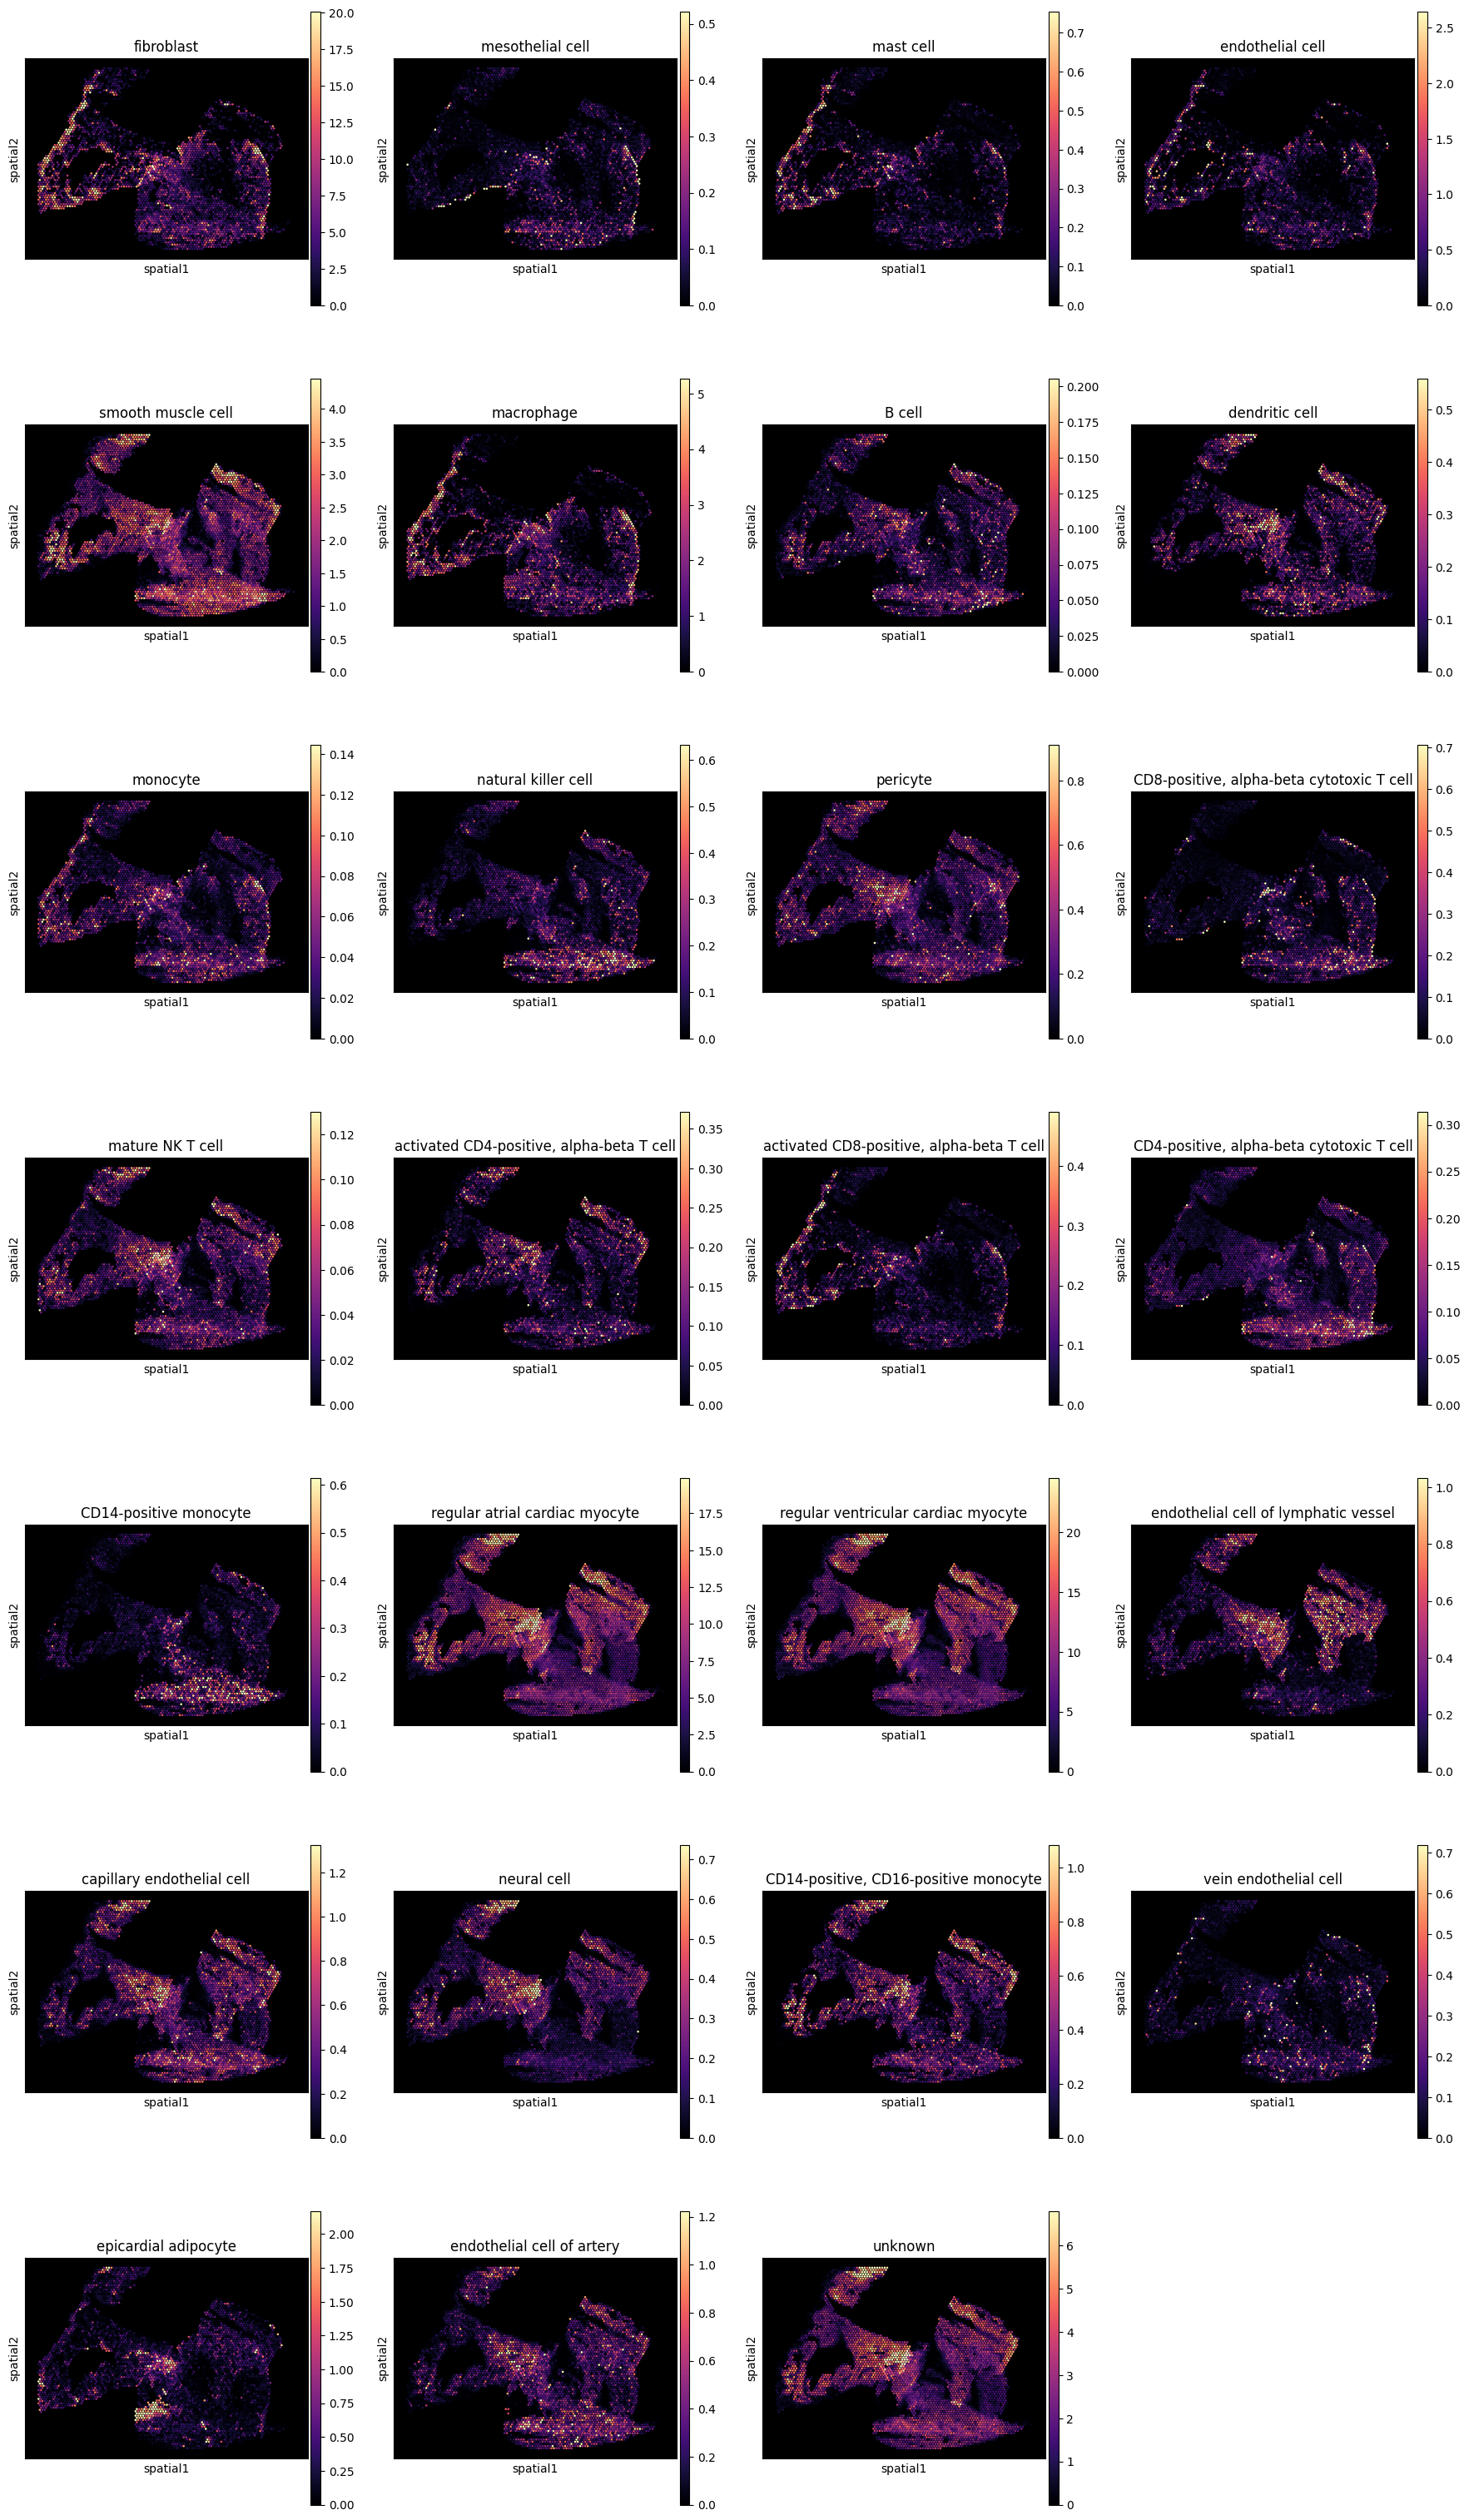

In [16]:
# Add q05 (confident) cell abundances to adata_vis.obs for spatial plotting.
if 'mod' in adata_vis.uns and 'factor_names' in adata_vis.uns['mod']:
    factor_names = list(adata_vis.uns['mod']['factor_names'])
    adata_vis.obs[factor_names] = adata_vis.obsm['q05_cell_abundance_w_sf']
    print(f"Added {len(factor_names)} cell type abundances to adata_vis.obs")
else:
    print("Warning: factor_names not found in adata_vis.uns['mod']")

available_cell_types = [ct for ct in factor_names if ct in adata_vis.obs.columns]
plot_cell_types = available_cell_types

with mpl.rc_context({'axes.facecolor': 'black',
                     'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(adata_vis, cmap='magma',
                  color=plot_cell_types,
                  ncols=4, size=1.3,
                  img_key=None,
                  library_id='HCAHeartST10238251',
                  vmin=0, vmax='p99.2')


### Merge related cell types for a clearer spatial view

Cardiac myocyte and endothelial subtypes are summed into coarser categories before plotting.

Plotting spatial abundance for: ['Cardiacmyocytes', 'Endothelial Cells', 'Fibroblast', 'Smooth Muscle Cells']


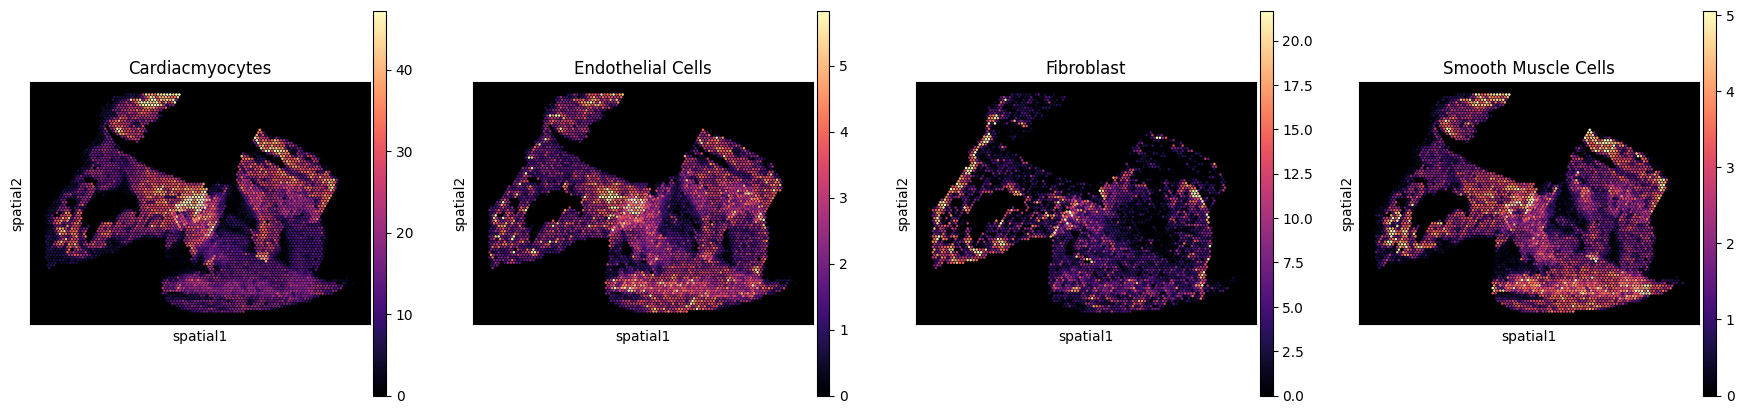

In [17]:
groups = {
    'Cardiacmyocytes':     [c for c in abundance_mean.columns if 'cardiac myocyte' in c.lower()],
    'Endothelial Cells':   [c for c in abundance_mean.columns if 'endothelial' in c.lower()],
    'Fibroblast':          ['fibroblast'],
    'Smooth Muscle Cells': ['smooth muscle cell'],
}

plot_cell_types = []
for name, cols in groups.items():
    valid_cols = [c for c in cols if c in abundance_mean.columns]
    if valid_cols:
        merged_series = abundance_mean[valid_cols].sum(axis=1)
        adata_vis.obs[name] = merged_series.reindex(adata_vis.obs_names).values
        plot_cell_types.append(name)

print(f"Plotting spatial abundance for: {plot_cell_types}")

with mpl.rc_context({'axes.facecolor': 'black',
                     'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(adata_vis, cmap='magma',
                  color=plot_cell_types,
                  ncols=4, size=1.3,
                  img_key=None,
                  library_id='HCAHeartST10238251',
                  vmin=0, vmax='p99.2')
plt.show()


### Marker-gene correlation permutation test

For each of the four coarse groups (Cardiacmyocytes, Fibroblast, Endothelial, Smooth Muscle), take the top 10 highly-expressed canonical markers and correlate their per-spot log-expression with the deconvolved cell-type abundance. Compare against a random background drawn from the high-expression gene pool. Marker CSVs are staged locally at `demo/data/markers/`.


Expression Threshold (80th percentile): 0.0708
High expression gene pool size: 6708
Created mapping for 33538 symbols from adata.var['SYMBOL'].

Analyzing Top 10 highly expressed marker genes...
  Cardiacmyocytes: Found 31 valid high-expression marker candidates.
  Fibroblast: Found 16 valid high-expression marker candidates.
  Endothelial Cells: Found 13 valid high-expression marker candidates.
  Smooth Muscle Cell: Found 9 valid high-expression marker candidates.


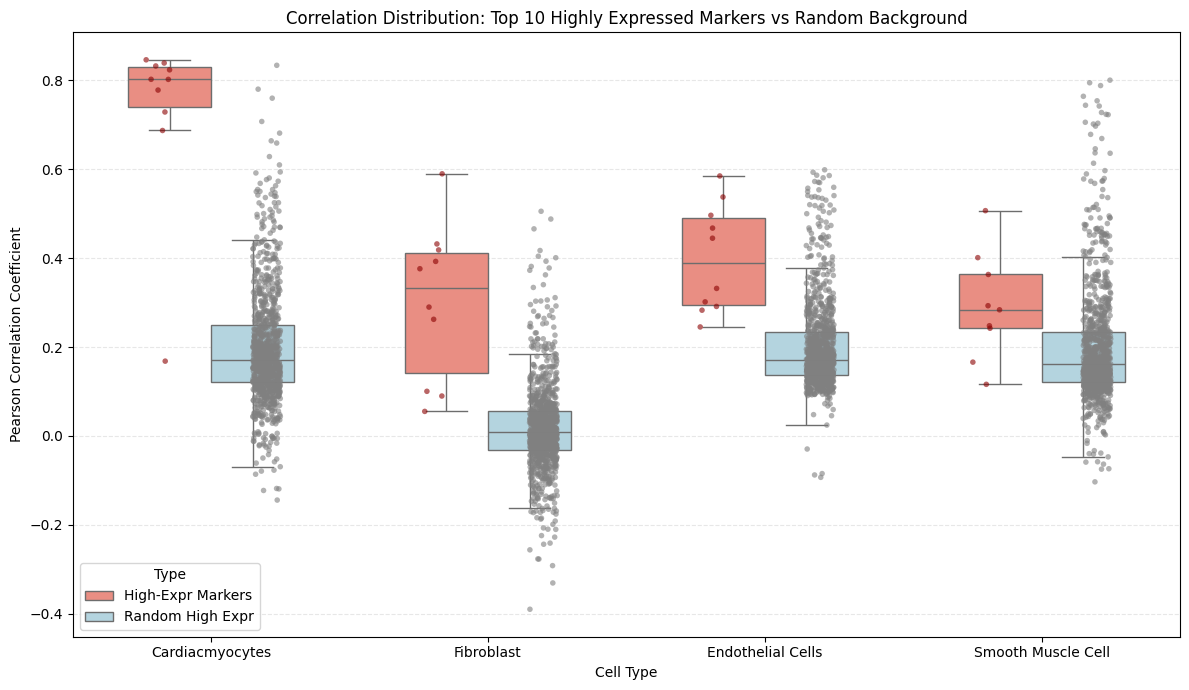


Summary of Top 10 Highly Expressed Markers:
         Cell Type Marker Gene  Correlation  P-value
   Cardiacmyocytes       TNNT2     0.846231 0.000999
   Cardiacmyocytes        MYH6     0.839005 0.000999
   Cardiacmyocytes        MYL4     0.832352 0.001998
   Cardiacmyocytes        MYL7     0.823678 0.001998
   Cardiacmyocytes       FABP3     0.802359 0.001998
   Cardiacmyocytes          MB     0.802211 0.001998
   Cardiacmyocytes         TTN     0.778153 0.002997
   Cardiacmyocytes       ACTC1     0.728816 0.003996
   Cardiacmyocytes        NPPA     0.687185 0.004995
   Cardiacmyocytes         DCN     0.168276 0.517483
 Endothelial Cells         VWF     0.584895 0.004995
 Endothelial Cells       IFI27     0.537548 0.015984
 Endothelial Cells         ENG     0.496426 0.028971
 Endothelial Cells      PECAM1     0.467630 0.036963
 Endothelial Cells        KLF2     0.444837 0.043956
 Endothelial Cells     CLEC14A     0.331885 0.095904
 Endothelial Cells        CDH5     0.301643 0.126873
 

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 0. Ensure unique variable names ---
adata_vis_ori.var_names_make_unique()

# --- 1. Threshold for "high expression" ---
if hasattr(adata_vis_ori.X, 'toarray'):
    mean_expr = np.array(adata_vis_ori.X.mean(axis=0)).flatten()
else:
    mean_expr = np.array(adata_vis_ori.X.mean(axis=0)).flatten()

expr_threshold = np.percentile(mean_expr, 80)
if expr_threshold == 0:
    print("80th percentile is 0. Using genes with mean expression > 0.")
    high_expr_indices = np.where(mean_expr > 0)[0]
else:
    print(f"Expression Threshold (80th percentile): {expr_threshold:.4f}")
    high_expr_indices = np.where(mean_expr >= expr_threshold)[0]

high_expr_genes_pool = set(adata_vis_ori.var_names[high_expr_indices])
print(f"High expression gene pool size: {len(high_expr_genes_pool)}")

# --- Symbol -> Ensembl mapping ---
symbol_to_ensg = {}
if 'SYMBOL' in adata_vis_ori.var.columns:
    for ensg, sym in zip(adata_vis_ori.var_names, adata_vis_ori.var['SYMBOL']):
        if pd.isna(sym):
            continue
        if sym in symbol_to_ensg:
            if ensg in high_expr_genes_pool and symbol_to_ensg[sym] not in high_expr_genes_pool:
                symbol_to_ensg[sym] = ensg
        else:
            symbol_to_ensg[sym] = ensg
    print(f"Created mapping for {len(symbol_to_ensg)} symbols from adata.var['SYMBOL'].")
else:
    print("Warning: 'SYMBOL' column not found in adata_vis_ori.var. Cannot map markers.")

# --- 2. Prepare merged cell-type abundances ---
merged_data = pd.DataFrame(index=abundance_mean.index)
groups = {}
for col in abundance_mean.columns:
    if 'endothelial' in col.lower():
        key = 'Endothelial Cells'
    elif 'cardiac myocyte' in col.lower():
        key = 'Cardiacmyocytes'
    else:
        key = col.title()
    groups.setdefault(key, []).append(col)
for key, cols in groups.items():
    merged_data[key] = abundance_mean[cols].sum(axis=1)

common_spots = adata_vis_ori.obs_names.intersection(merged_data.index)
adata_vis_ori_aligned = adata_vis_ori[common_spots, :]
merged_data_aligned = merged_data.loc[common_spots]

# --- 3. Target cell types & local marker files ---
MARKER_DIR = Path.cwd() / "data" / "markers"
top_cell_types = ['Cardiacmyocytes', 'Fibroblast', 'Endothelial Cells', 'Smooth Muscle Cell']
marker_files = {
    'Cardiacmyocytes':     MARKER_DIR / "cardiomyocyte_markers.csv",
    'Fibroblast':          MARKER_DIR / "fibroblast_markers.csv",
    'Endothelial Cells':   MARKER_DIR / "endothelial_markers.csv",
    'Smooth Muscle Cell':  MARKER_DIR / "smoothmuscle_markers.csv",
}

# --- 4. Top-10 high-expr markers + random permutation test ---
results = []
random_results = []
print("\nAnalyzing Top 10 highly expressed marker genes...")
np.random.seed(42)

for cell_type in top_cell_types:
    file_path = marker_files.get(cell_type)
    if file_path is None or not file_path.exists():
        print(f"  {cell_type}: Marker file not found ({file_path}).")
        continue

    try:
        df_markers = pd.read_csv(file_path)
        if 'marker' in df_markers.columns:
            marker_symbols = df_markers['marker'].unique()
        else:
            marker_symbols = df_markers.iloc[:, 0].unique()

        valid_candidate_ids = []
        for sym in marker_symbols:
            if sym in high_expr_genes_pool:
                valid_candidate_ids.append(sym)
            elif sym in symbol_to_ensg:
                ensg = symbol_to_ensg[sym]
                if ensg in high_expr_genes_pool:
                    valid_candidate_ids.append(ensg)
        valid_candidate_ids = list(set(valid_candidate_ids))
        if not valid_candidate_ids:
            print(f"  {cell_type}: No valid high-expression marker candidates found.")
            continue
        print(f"  {cell_type}: Found {len(valid_candidate_ids)} valid high-expression marker candidates.")

        candidate_mean_expressions = {
            gene_id: mean_expr[adata_vis_ori_aligned.var_names.get_loc(gene_id)]
            for gene_id in valid_candidate_ids
        }
        sorted_candidates = sorted(candidate_mean_expressions.items(), key=lambda item: item[1], reverse=True)
        top_10_ids = [g for g, _ in sorted_candidates[:10]]

        id_to_symbol_display = {v: k for k, v in symbol_to_ensg.items() if v in top_10_ids}

        if cell_type not in merged_data_aligned.columns:
            print(f"  {cell_type}: not found in merged abundances, skipping.")
            continue
        cell_abund_vals = merged_data_aligned[cell_type].values

        for gene_id in top_10_ids:
            if hasattr(adata_vis_ori_aligned.X, 'toarray'):
                gene_counts = adata_vis_ori_aligned[:, gene_id].X.toarray().flatten()
            else:
                gene_counts = adata_vis_ori_aligned[:, gene_id].X.flatten()
            if np.std(gene_counts) == 0:
                continue
            gene_expr_vals = np.log10(gene_counts + 1)
            marker_corr = np.corrcoef(gene_expr_vals, cell_abund_vals)[0, 1]
            if not np.isnan(marker_corr):
                disp_name = id_to_symbol_display.get(gene_id, gene_id)
                results.append({'Cell Type': cell_type, 'Marker Gene': disp_name,
                                'Correlation': marker_corr, 'Type': 'High-Expr Markers'})

        current_random_pool = list(high_expr_genes_pool - set(valid_candidate_ids))
        n_random_samples = min(1000, len(current_random_pool))
        if n_random_samples > 0:
            random_genes_sample = np.random.choice(current_random_pool, size=n_random_samples, replace=False)
            random_expression_data = adata_vis_ori_aligned[:, random_genes_sample].X
            if hasattr(random_expression_data, 'toarray'):
                random_expression_data = random_expression_data.toarray()
            random_expression_data = np.log10(random_expression_data + 1)

            X_centered = random_expression_data - random_expression_data.mean(axis=0)
            y_centered = cell_abund_vals - cell_abund_vals.mean()
            numerator = np.dot(y_centered, X_centered)
            ssd_x = np.sqrt(np.sum(X_centered**2, axis=0))
            ssd_y = np.sqrt(np.sum(y_centered**2))
            with np.errstate(divide='ignore', invalid='ignore'):
                random_corrs = numerator / (ssd_x * ssd_y)
            random_corrs = random_corrs[~np.isnan(random_corrs)]

            for rc in random_corrs:
                random_results.append({'Cell Type': cell_type, 'Correlation': rc, 'Type': 'Random High Expr'})

            for res in results:
                if res['Cell Type'] == cell_type and 'P-value' not in res:
                    n_greater = np.sum(random_corrs >= res['Correlation'])
                    res['P-value'] = (n_greater + 1) / (len(random_corrs) + 1)
        else:
            for res in results:
                if res['Cell Type'] == cell_type:
                    res['P-value'] = np.nan
    except Exception as e:
        print(f"  Error processing {cell_type}: {e}")

# --- 5. Plot ---
if results:
    df_results = pd.DataFrame(results)
    df_random = pd.DataFrame(random_results)
    df_combined = pd.concat([df_results, df_random], ignore_index=True)

    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_combined, x='Cell Type', y='Correlation', hue='Type',
                palette={'Random High Expr': 'lightblue', 'High-Expr Markers': 'salmon'},
                showfliers=False, width=0.6)
    sns.stripplot(data=df_combined, x='Cell Type', y='Correlation', hue='Type',
                  palette={'Random High Expr': 'gray', 'High-Expr Markers': 'darkred'},
                  size=4, jitter=True, dodge=True, alpha=0.6, zorder=5, legend=False)
    plt.title('Correlation Distribution: Top 10 Highly Expressed Markers vs Random Background')
    plt.ylabel('Pearson Correlation Coefficient')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nSummary of Top 10 Highly Expressed Markers:")
    print(df_results[['Cell Type', 'Marker Gene', 'Correlation', 'P-value']]
          .sort_values(['Cell Type', 'Correlation'], ascending=[True, False])
          .to_string(index=False))
else:
    print("No results to plot.")


### Overall spatial cell-type composition

Pie chart of aggregated per-spot abundances, with the top 4 merged groups plus "Others".

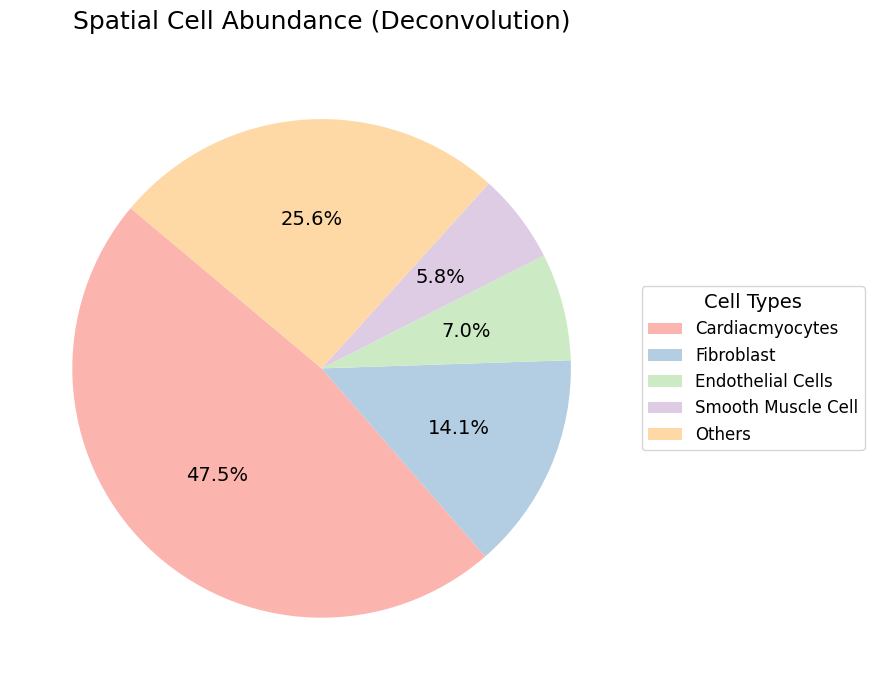

In [19]:
spatial_counts = abundance_mean.sum(axis=0)
spatial_props = spatial_counts / spatial_counts.sum()

def _merge_cell_types(props: pd.Series) -> pd.Series:
    merged = {}
    for cell_type, value in props.items():
        if "endothelial" in cell_type.lower():
            key = "Endothelial Cells"
        elif "cardiac myocyte" in cell_type.lower():
            key = "Cardiacmyocytes"
        else:
            key = cell_type
        merged[key] = merged.get(key, 0) + value
    return pd.Series(merged).sort_values(ascending=False)

spatial_merged = _merge_cell_types(spatial_props)
candidates = spatial_merged.drop("unknown", errors="ignore")
top_4 = candidates.nlargest(4).index.tolist()

kept = spatial_merged[spatial_merged.index.isin(top_4)]
others_sum = spatial_merged[~spatial_merged.index.isin(top_4)].sum()
pie_data = kept.copy()
pie_data["Others"] = others_sum
pie_data.index = pie_data.index.str.title()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Pastel1.colors
if len(pie_data) > len(colors):
    colors = plt.cm.tab20c.colors

wedges, _texts, autotexts = ax.pie(
    pie_data,
    labels=None,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors[: len(pie_data)],
    pctdistance=0.6,
    textprops={"fontsize": 14},
)
ax.set_title("Spatial Cell Abundance (Deconvolution)", fontsize=18, pad=20)
ax.legend(
    wedges,
    pie_data.index,
    title="Cell Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=12,
    title_fontsize=14,
)
plt.tight_layout()
plt.show()